# **Bag of words**

### **One of the simplest and common methods for representing text data in numerical form at that**
### **machine learning models can process**

### **Example :**
### *-sentence 1 : I Love NLP*
### *-sentence 2 : NLP is amazing*
### *-sentence 3 : NLP Engineer*

### **after lowcase letters and stopwords remove :**
### *-sentence 1 : Love NLP*
### *-sentence 2 : NLP amazing*
### *-sentence 3 : NLP Engineer*

![bag_of_words](Bagof.png)

### Note that if the vocabulary is large, most entries in the BOW matrix are zero since most
### documents will not contain most words in the vocabulary

In [2]:
from nltk import word_tokenize, sent_tokenize, pos_tag , WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
import string
import pandas as pd

# phase one :  load document
with open('Test_text.txt','r+') as file :
    text = file.read()

# phase two :  convert loaded document into dataframe
sentences = sent_tokenize(text)

data = pd.DataFrame(sentences,columns=["text"])

# phase three : preprocessing and normalization
def get_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    elif tag.startswith('N'):
        return wordnet.NOUN
    return wordnet.NOUN

def data_preprocessing(data_row):
    
    tokens = word_tokenize(data_row)
    stopWords = set(stopwords.words('arabic'))
    punctuation = set(string.punctuation)
    lemmatizer = WordNetLemmatizer()
    tags = pos_tag(tokens)
    
    new_tokens = [ lemmatizer.lemmatize(word.lower(),get_pos(tag)) for word,tag in tags 
                   if ( word not in stopWords ) and ( word not in punctuation ) and ( word.isdigit() == 0)]
    
    
    return " ".join(new_tokens)

data['processed'] = data['text'].apply(data_preprocessing)

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

dt = data['processed']
cv = CountVectorizer()
x = cv.fit_transform(dt).toarray()

x

array([[0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(24, 465))

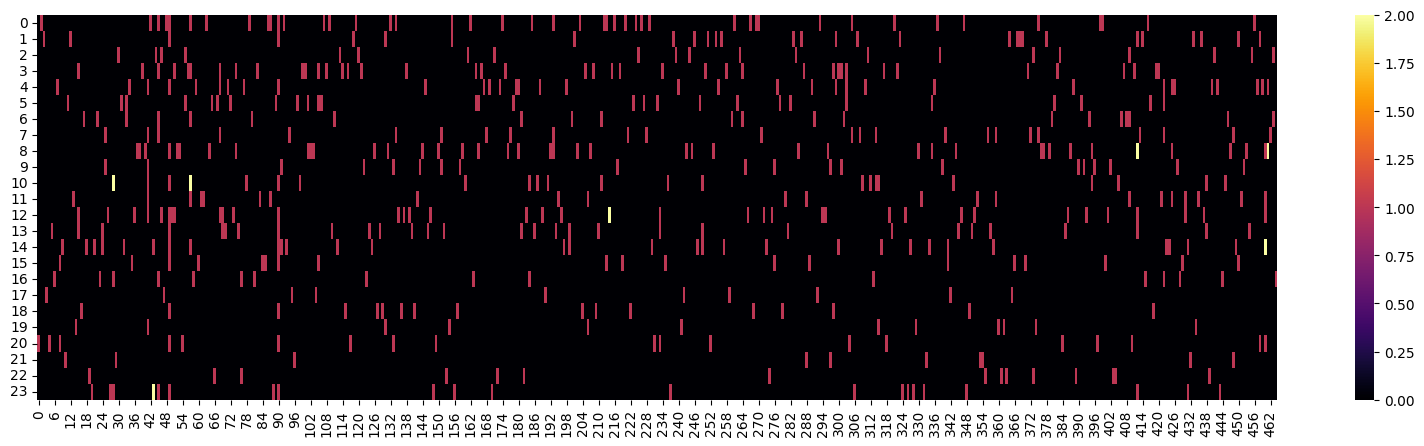

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))
sns.heatmap(x,cmap='inferno')

plt.show()

### **Limitation of BOW**
### **[1] Loss of Context**
### ignores word order and context which means it might miss important relationships between words
### **[2] Limited semantic understanding**
### the model doesn't capture the meaning of words which can be important for some nlp tasks
### **[3] Sparsity**
### when working with large datasets, most word vectors will be sparse which can lead to inefficiency 


# **N-grams**

## Continuous sequence of n items from a given text or speech, the items can be letters, words or
## base pairs according to the application

![N_grams](ngrams.png)

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
dt = data['processed']
cv = CountVectorizer(ngram_range=(1,190))
x = cv.fit_transform(dt).toarray()

print(x.shape)

(24, 8672)


## **TF - IDF ( Term frequency - Inverse Document frequency )**

## **statistical measure used to evaluate how important a word is to a document within a collection**
## **of corpus**
![TF-IDF](tf-idf.png)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

cv = TfidfVectorizer(ngram_range=(1,5))

x = cv.fit_transform(dt).toarray()

print(x.shape)

(24, 2586)
